#  Парциальное разложение

Рассчет аналитического решения для волнового пакета, находящемся в потенциале Юкавы

In [51]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.special import legendre
import matplotlib.pyplot as plt

In [92]:
k0 = 2.0
V0 = 5.0
R_param = 2.0
sigma_x = 3.0


def V(r):
    return V0 * np.exp(-r/R_param)/(r+1e-3)

def A_k(k):
    return (2*sigma_x**2/np.pi)**0.25 * np.exp(-sigma_x**2 * (k - k0)**2)

## Теория
Работаем со стационарным уравненим Шрёдингера в сферически симметричном представлении:
$$−\nabla^2\psi+V(r)\psi=k^2\psi$$
Подставляем волновую функцию в форме Лежандра $\psi(r,\theta,\phi) = \frac{\chi_l(r)}{r} P_l (cos\theta)$, что сводит к одномерному уравнению:
$$\frac{d^2 \chi_l(r)}{d r^2} + \left[k_0^2 - V(r) - \frac{l(l+1)}{r^2}\right]\chi_l(r) = 0$$

### Граничные условия
$$\chi_l (0) = 0 \quad \chi_l(r) \underset{r \to \infty}{\to} A_l \sin\left(k r - \frac{l\pi}{2} + \delta_l\right)$$
где $A_l$ - нормировочный член, $\delta_l$ - сдвиг по фазе

### Функция рассеяния
$$\frac{d\sigma}{d\Omega} = \frac{1}{k_0^2} \left|\sum_{l=0}^{\infty} (2l+1) e^{i\delta_l} \sin{\delta_l}  P_l(cos\theta)\right|^2 $$

In [5]:
import sys
print(sys.float_info)

sys.float_info(max=1.7976931348623157e+308, max_exp=1024, max_10_exp=308, min=2.2250738585072014e-308, min_exp=-1021, min_10_exp=-307, dig=15, mant_dig=53, epsilon=2.220446049250313e-16, radix=2, rounds=1)


2e-308 - предел переполнения в питоне, будем ограничиваться 1e-100

In [93]:
L = 120.0  # длина системы
dr = 0.05
N = int(L/dr)

dk = 0.1
k_values = np.arange(k0 - 3/(2*sigma_x), k0 + 3/(2*sigma_x) + dk, dk)

l_max = 60
theta = np.linspace(0, np.pi, 300)


f_k_array = np.zeros((len(k_values), len(theta)), dtype=complex)

for idx, k in enumerate(k_values):
    delta_l = np.zeros(l_max + 1)

    for l in range(l_max + 1):
        r_min = (l + 1) / k + 0.5

        def delta_ode(r, d):
            return -1/k * V(r) * np.sin(k*r - l*np.pi/2 + d)**2

        sol = solve_ivp(delta_ode, [r_min, L], [0],
                        method='RK45', rtol=1e-9, atol=1e-12,
                        max_step=0.05)

        delta_l[l] = np.mod(sol.y[0,-1] + np.pi, 2*np.pi) - np.pi

    f = np.zeros_like(theta, dtype=complex)
    for l in range(l_max + 1):
        Pl = legendre(l)(np.cos(theta))
        f += (2*l + 1) * np.exp(1j * delta_l[l]) * np.sin(delta_l[l]) * Pl
    f /= k

    f_k_array[idx] = f

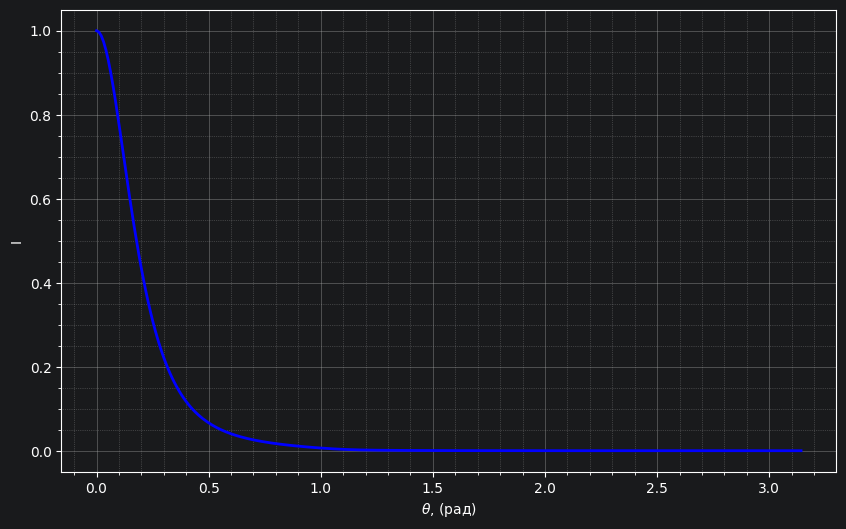

In [97]:
f_total = np.zeros_like(theta, dtype=complex)
for idx, k in enumerate(k_values):
    weight = A_k(k) * dk
    f_total += weight * f_k_array[idx]

I_total = np.abs(f_total)**2
I_norm_teor = I_total / np.max(I_total)

plt.figure(figsize=(10, 6))
plt.plot(theta, I_norm_teor, 'b-', lw=2)
plt.xlabel(r'$\theta$, (рад)')
plt.ylabel('I')
plt.minorticks_on()
plt.grid(True, which='major')
plt.grid(True, which='minor', linestyle=':', alpha=0.5)
plt.show()

    ## Результаты моделирования

In [80]:
frames = np.load('frames_3d.npy')

In [81]:
L = 100.0  # длина системы
N = 144  # дискретизация

x = np.linspace(-L / 2, L / 2, N)
y = np.linspace(-L / 2, L / 2, N)
z = np.linspace(-L / 2, L / 2, N)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')
R = np.sqrt(X**2 + Y**2 + Z**2)

dx = L/N

## График нормы от времени
Необходимо для выбора момента до начала поглощения, для сравнения асимптотического распределения из парциального разложения с угловым распределением моделирования

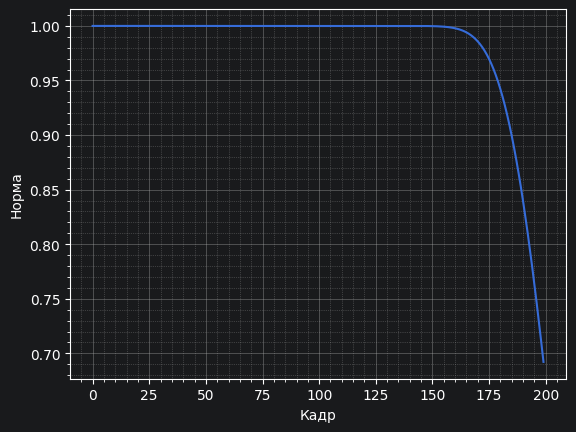

In [82]:
norms = [np.sum(f) * dx**3 for f in frames]
plt.plot(norms)
plt.xlabel('Кадр')
plt.ylabel('Норма')
plt.minorticks_on()
plt.grid(True, which='major')
plt.grid(True, which='minor', linestyle=':', alpha=0.5)
plt.show()

кадр 130

## Угловое распределение моделирования
$$r = \sqrt{x^2 + y^2 + z^2} \quad \theta = \text{arctg}\left(\frac{\sqrt{y^2+z^2}}{x}\right)$$

In [104]:
frame = frames[150]

teta = np.arctan2(np.sqrt(Y ** 2 + Z ** 2), X)
bins = np.linspace(0, np.pi, 60)

I_teta_model = np.zeros(len(bins) - 1)

for i in range(len(bins) - 1):
    I_teta_model[i] = np.mean(frame[(teta >= bins[i]) & (teta < bins[i + 1])])

teta_grph_model = 0.5 * (bins[1:] + bins[:-1])

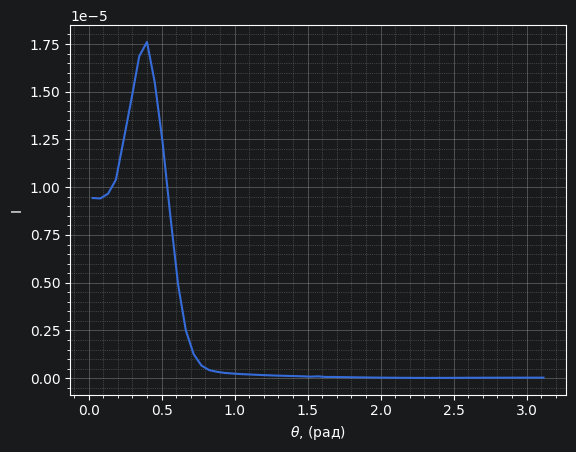

In [103]:
plt.plot(teta_grph_model, I_teta_model)
plt.xlabel(r'$\theta$, (рад)')
plt.ylabel('I')
plt.minorticks_on()
plt.grid(True, which='major')
plt.grid(True, which='minor', linestyle=':', alpha=0.5)
plt.show()

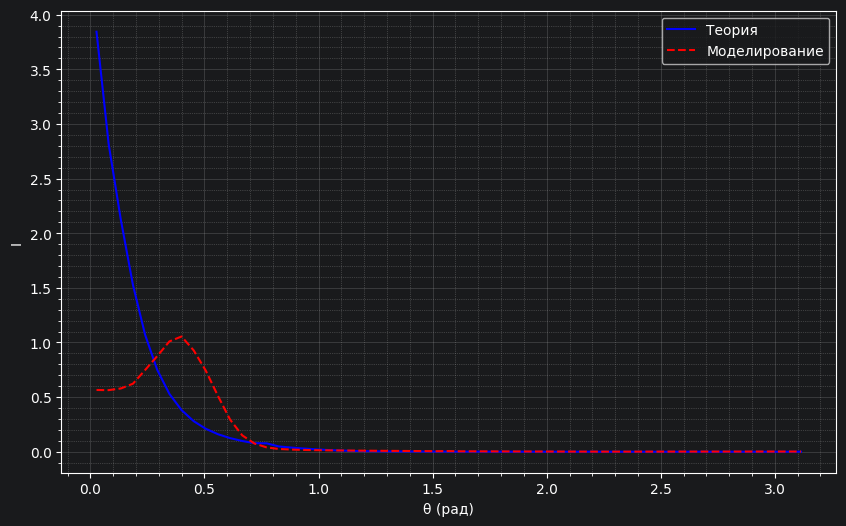

In [111]:
element = 2 * np.pi * np.sin(theta)
sigma_tot = np.trapezoid(I_norm_teor * element, theta)
P_teor = I_norm_teor / sigma_tot

bins = np.linspace(0, np.pi, 60)
teta_mid = 0.5 * (bins[:-1] + bins[1:])
P_teor_bin = np.zeros_like(teta_mid)

for i in range(len(bins)-1):
    mask = (theta >= bins[i]) & (theta < bins[i+1])
    if np.any(mask):
        prob = np.trapezoid(P_teor[mask] * element[mask], theta[mask])
        d_o = 2 * np.pi * (np.cos(bins[i]) - np.cos(bins[i+1]))
        P_teor_bin[i] = prob / d_o

frame = frames[150]
teta = np.arctan2(np.sqrt(Y**2 + Z**2), X)

I_sim = np.zeros(len(bins) - 1)
for i in range(len(bins) - 1):
    mask = (teta >= bins[i]) & (teta < bins[i + 1])
    if np.any(mask):
        I_sim[i] = np.mean(frame[mask])

d_o_bin = 2 * np.pi * (np.cos(bins[:-1]) - np.cos(bins[1:]))
P_sim = I_sim / np.sum(I_sim * d_o_bin)

plt.figure(figsize=(10, 6))
plt.plot(teta_mid, P_teor_bin, 'b-', label='Теория')
plt.plot(teta_mid, P_sim, 'r--', label='Моделирование')
plt.xlabel('θ (рад)')
plt.ylabel('I')
plt.minorticks_on()
plt.grid(True, which='major')
plt.grid(True, which='minor', linestyle=':', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()